In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("master_stock_data.csv")
df["date"] = pd.to_datetime(df["date"])

df.sort_values(["symbol", "date"], inplace=True)

df.head()

,date,symbol,open,high,low,close,volume
0,2023-10-03 05:30:00,ADANI ENTERPRISES: ADANIGREEN,596.6,604.90,589.60,602.95,15322196
1,2023-10-04 05:30:00,ADANI ENTERPRISES: ADANIGREEN,600.0,600.45,584.45,586.25,24914612
2,2023-10-05 05:30:00,ADANI ENTERPRISES: ADANIGREEN,590.0,594.35,587.10,592.15,13248028
3,2023-10-06 05:30:00,ADANI ENTERPRISES: ADANIGREEN,593.4,598.95,592.20,594.25,8216780
4,2023-10-09 05:30:00,ADANI ENTERPRISES: ADANIGREEN,588.0,589.00,581.55,585.10,9189597


In [32]:
df["symbol"] = df["symbol"].str.split(":").str[-1].str.strip()

print("Clean Symbols:")
print(df["symbol"].unique()[:5])

Clean Symbols:
['ADANIGREEN' 'ADANIPORTS' 'APOLLOHOSP' 'ASIANPAINT' 'AXISBANK']


In [36]:
df["date"] = pd.to_datetime(df["date"])
df.sort_values(["symbol", "date"], inplace=True)

In [38]:
df["daily_return"] = df.groupby("symbol")["close"].pct_change()

df.head()

,date,symbol,open,high,low,close,volume,daily_return
0,2023-10-03 05:30:00,ADANIGREEN,596.6,604.90,589.60,602.95,15322196,NaN
1,2023-10-04 05:30:00,ADANIGREEN,600.0,600.45,584.45,586.25,24914612,-0.027697
2,2023-10-05 05:30:00,ADANIGREEN,590.0,594.35,587.10,592.15,13248028,0.010064
3,2023-10-06 05:30:00,ADANIGREEN,593.4,598.95,592.20,594.25,8216780,0.003546
4,2023-10-09 05:30:00,ADANIGREEN,588.0,589.00,581.55,585.10,9189597,-0.015398


In [42]:
# Get first and last closing price for each stock
first_price = df.groupby("symbol")["close"].first()
last_price = df.groupby("symbol")["close"].last()

# Calculate yearly return
yearly_return = ((last_price - first_price) / first_price).reset_index()
yearly_return.columns = ["symbol", "yearly_return"]

yearly_return.sort_values("yearly_return", ascending=False).head()

,symbol,yearly_return
13,DRREDDY,2.230926
26,ITC,1.017601
21,HINDUNILVR,0.959770
49,WIPRO,0.890112
14,EICHERMOT,0.695990


In [44]:
top_10_green = yearly_return.sort_values(
    "yearly_return", ascending=False
).head(10)

top_10_green

,symbol,yearly_return
13,DRREDDY,2.230926
26,ITC,1.017601
21,HINDUNILVR,0.959770
49,WIPRO,0.890112
14,EICHERMOT,0.695990
11,CIPLA,0.688549
42,TATAMOTORS,0.674772
46,TITAN,0.589767
36,RELIANCE,0.572824
9,BEL,0.532574


In [46]:
top_10_red = yearly_return.sort_values(
    "yearly_return"
).head(10)

top_10_red

,symbol,yearly_return
31,MARUTI,-0.304584
32,NESTLEIND,-0.219350
1,ADANIPORTS,-0.161109
24,INFY,-0.066709
19,HEROMOTOCO,-0.009579
39,SHRIRAMFIN,0.007071
38,SBIN,0.019918
27,JSWSTEEL,0.025496
3,APOLLOHOSP,0.035182
30,M&M,0.069267


In [48]:
volatility = df.groupby("symbol")["daily_return"].std().reset_index()
volatility.columns = ["symbol", "volatility"]

volatility.sort_values("volatility", ascending=False).head()

,symbol,volatility
24,INFY,0.028601
25,IOC,0.026029
26,ITC,0.023283
13,DRREDDY,0.023074
40,SUNPHARMA,0.022247


In [50]:
top_10_volatile = volatility.sort_values(
    "volatility", ascending=False
).head(10)

top_10_volatile

,symbol,volatility
24,INFY,0.028601
25,IOC,0.026029
26,ITC,0.023283
13,DRREDDY,0.023074
40,SUNPHARMA,0.022247
42,TATAMOTORS,0.022069
37,SBILIFE,0.021687
29,LT,0.021411
45,TECHM,0.019587
18,HDFCLIFE,0.019475


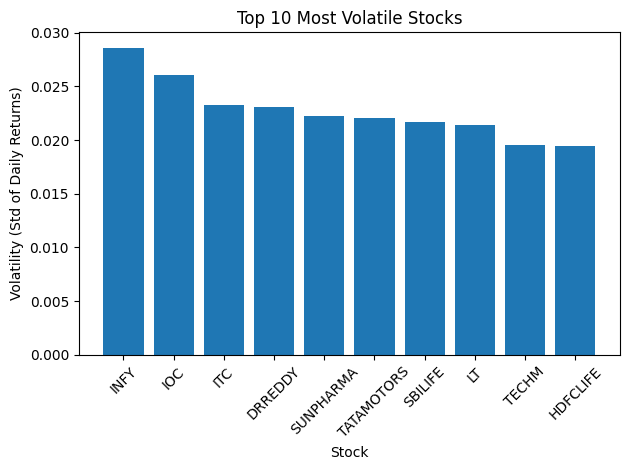

In [52]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(top_10_volatile["symbol"], top_10_volatile["volatility"])
plt.xticks(rotation=45)
plt.title("Top 10 Most Volatile Stocks")
plt.xlabel("Stock")
plt.ylabel("Volatility (Std of Daily Returns)")
plt.tight_layout()
plt.show()

In [56]:
df["cumulative_return"] = (
    (1 + df["daily_return"])
    .groupby(df["symbol"])
    .cumprod()
)

In [58]:
top5_symbols = yearly_return.sort_values(
    "yearly_return", ascending=False
).head(5)["symbol"]

top5_symbols

13       DRREDDY
26           ITC
21    HINDUNILVR
49         WIPRO
14     EICHERMOT
Name: symbol, dtype: object

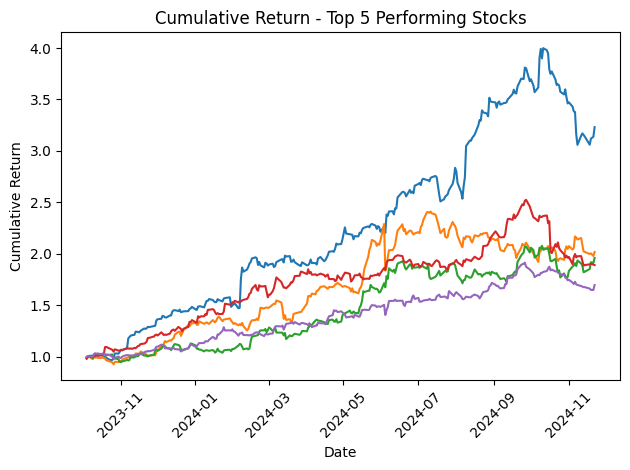

In [60]:
import matplotlib.pyplot as plt

plt.figure()

for symbol in top5_symbols:
    stock_data = df[df["symbol"] == symbol]
    plt.plot(stock_data["date"], stock_data["cumulative_return"])

plt.title("Cumulative Return - Top 5 Performing Stocks")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [62]:
price_matrix = df.pivot(index="date", columns="symbol", values="close")

price_matrix.head()

symbol,ADANIGREEN,ADANIPORTS,AIRTEL,APOLLOHOSP,ASIANPAINT,AXISBANK,BAJAJ-AUTO,BAJAJFINSV,BAJFINANCE,BEL,...,SUNPHARMA,TATACONSUMER,TATAMOTORS,TATASTEEL,TCS,TECHM,TITAN,TRENT,ULTRACEMCO,WIPRO
date,,,,,,,,,,,,,,,,,,,,,
2023-10-03 05:30:00,602.95,7967.60,770.25,3196.25,439.75,3513.85,3073.25,1159.08,861.20,1238.70,...,184.60,1182.80,170.68,4495.45,1292.45,479.95,3015.60,1041.05,1508.05,5016.45
2023-10-04 05:30:00,586.25,7854.05,756.60,3166.65,436.10,3537.75,3027.75,1157.08,854.13,1239.55,...,182.75,1167.05,170.68,4532.50,1270.55,473.40,2989.05,995.55,1529.55,4918.60
2023-10-05 05:30:00,592.15,7850.90,755.50,3216.50,436.05,3589.35,3096.05,1157.05,849.64,1235.45,...,182.20,1161.10,172.23,4533.90,1274.45,470.55,3016.65,1003.25,1535.75,5011.05
2023-10-06 05:30:00,594.25,8168.55,765.20,3309.75,442.15,3621.40,3093.70,1159.00,864.01,1237.70,...,181.45,1163.00,173.60,4538.45,1282.95,472.60,3038.00,1000.95,1534.05,5014.60
2023-10-09 05:30:00,585.10,8027.70,757.55,3267.50,440.45,3638.35,3074.70,1149.13,869.84,1249.60,...,181.70,1159.50,170.00,4522.50,1277.25,469.80,2955.10,996.25,1516.25,5007.30


In [64]:
correlation_matrix = price_matrix.corr()

correlation_matrix.head()

symbol,ADANIGREEN,ADANIPORTS,AIRTEL,APOLLOHOSP,ASIANPAINT,AXISBANK,BAJAJ-AUTO,BAJAJFINSV,BAJFINANCE,BEL,...,SUNPHARMA,TATACONSUMER,TATAMOTORS,TATASTEEL,TCS,TECHM,TITAN,TRENT,ULTRACEMCO,WIPRO
symbol,,,,,,,,,,,,,,,,,,,,,
ADANIGREEN,1.000000,-0.517513,0.782661,-0.053783,0.241965,0.722459,0.740840,0.801227,0.641012,0.537373,...,0.879565,0.846458,0.898238,0.642053,0.581682,0.809466,0.865972,0.772675,0.320488,0.851753
ADANIPORTS,-0.517513,1.000000,-0.155670,0.038963,0.202961,-0.415928,-0.325636,-0.473331,-0.422037,-0.345507,...,-0.531658,-0.416787,-0.553193,-0.099784,-0.154123,-0.201775,-0.375013,-0.155250,0.250851,-0.322937
AIRTEL,0.782661,-0.155670,1.000000,0.025734,0.625418,0.686431,0.670696,0.518113,0.451756,0.685142,...,0.680428,0.806524,0.773757,0.840914,0.741767,0.937846,0.823898,0.811117,0.719489,0.883737
APOLLOHOSP,-0.053783,0.038963,0.025734,1.000000,0.086942,0.316746,0.462556,0.357508,0.556552,0.305585,...,0.158310,0.193035,0.235149,0.129959,0.268693,-0.011419,0.200300,0.002643,-0.095771,0.199710
ASIANPAINT,0.241965,0.202961,0.625418,0.086942,1.000000,0.563023,0.312217,0.082414,0.273793,0.557528,...,0.389809,0.473804,0.357170,0.785989,0.785547,0.558063,0.428719,0.464064,0.716869,0.520786


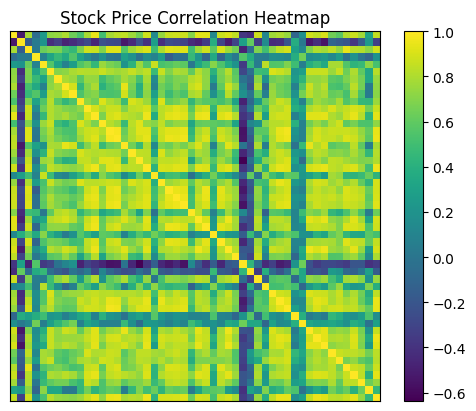

In [66]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(correlation_matrix)
plt.colorbar()
plt.title("Stock Price Correlation Heatmap")
plt.xticks([])
plt.yticks([])
plt.show()

In [70]:
import pandas as pd

SECTOR_FILE = r"C:\Users\karth\Downloads\Sector_data - Sheet1.csv"

In [72]:
sector_df = pd.read_csv(SECTOR_FILE)

sector_df.head()

,COMPANY,sector,Symbol
0,ADANI ENTERPRISES,MISCELLANEOUS,ADANI ENTERPRISES: ADANIGREEN
1,ADANI PORTS & SEZ,MISCELLANEOUS,ADANI PORTS & SEZ: ADANIPORTS
2,APOLLO HOSPITALS,MISCELLANEOUS,APOLLO HOSPITALS: APOLLOHOSP
3,ASIAN PAINTS,PAINTS,ASIAN PAINTS: ASIANPAINT
4,AXIS BANK,BANKING,AXIS BANK: AXISBANK


In [78]:
sector_df["Symbol"] = sector_df["Symbol"].str.strip()

In [80]:
sector_performance = yearly_return.merge(
    sector_df,
    left_on="symbol",
    right_on="Symbol",
    how="left"
)

In [82]:
print(sector_performance.head())
print(sector_performance.shape)

       symbol  yearly_return COMPANY sector Symbol
0  ADANIGREEN       0.353429     NaN    NaN    NaN
1  ADANIPORTS      -0.161109     NaN    NaN    NaN
2      AIRTEL       0.268874     NaN    NaN    NaN
3  APOLLOHOSP       0.035182     NaN    NaN    NaN
4  ASIANPAINT       0.079363     NaN    NaN    NaN
(50, 5)


In [84]:
print("Sample yearly_return symbols:")
print(yearly_return["symbol"].unique()[:10])

print("\nSample sector file symbols:")
print(sector_df["Symbol"].unique()[:10])

Sample yearly_return symbols:
['ADANIGREEN' 'ADANIPORTS' 'AIRTEL' 'APOLLOHOSP' 'ASIANPAINT' 'AXISBANK'
 'BAJAJ-AUTO' 'BAJAJFINSV' 'BAJFINANCE' 'BEL']

Sample sector file symbols:
['ADANI ENTERPRISES: ADANIGREEN' 'ADANI PORTS & SEZ: ADANIPORTS'
 'APOLLO HOSPITALS: APOLLOHOSP' 'ASIAN PAINTS: ASIANPAINT'
 'AXIS BANK: AXISBANK' 'BAJAJ AUTO: BAJAJ-AUTO'
 'BAJAJ FINANCE: BAJFINANCE' 'BAJAJ FINSERV: BAJAJFINSV'
 'BHARAT ELECTRONICS: BEL' 'BHARTI AIRTEL: AIRTEL']


In [86]:
sector_df.head()

,COMPANY,sector,Symbol
0,ADANI ENTERPRISES,MISCELLANEOUS,ADANI ENTERPRISES: ADANIGREEN
1,ADANI PORTS & SEZ,MISCELLANEOUS,ADANI PORTS & SEZ: ADANIPORTS
2,APOLLO HOSPITALS,MISCELLANEOUS,APOLLO HOSPITALS: APOLLOHOSP
3,ASIAN PAINTS,PAINTS,ASIAN PAINTS: ASIANPAINT
4,AXIS BANK,BANKING,AXIS BANK: AXISBANK


In [88]:
sector_df["ticker"] = sector_df["Symbol"].str.split(":").str[1].str.strip()
sector_df.head()

,COMPANY,sector,Symbol,ticker
0,ADANI ENTERPRISES,MISCELLANEOUS,ADANI ENTERPRISES: ADANIGREEN,ADANIGREEN
1,ADANI PORTS & SEZ,MISCELLANEOUS,ADANI PORTS & SEZ: ADANIPORTS,ADANIPORTS
2,APOLLO HOSPITALS,MISCELLANEOUS,APOLLO HOSPITALS: APOLLOHOSP,APOLLOHOSP
3,ASIAN PAINTS,PAINTS,ASIAN PAINTS: ASIANPAINT,ASIANPAINT
4,AXIS BANK,BANKING,AXIS BANK: AXISBANK,AXISBANK


In [90]:
merged = yearly_return.merge(
    sector_df[["ticker", "COMPANY", "sector"]],
    left_on="symbol",
    right_on="ticker",
    how="left"
)

merged.head()

,symbol,yearly_return,ticker,COMPANY,sector
0,ADANIGREEN,0.353429,ADANIGREEN,ADANI ENTERPRISES,MISCELLANEOUS
1,ADANIPORTS,-0.161109,ADANIPORTS,ADANI PORTS & SEZ,MISCELLANEOUS
2,AIRTEL,0.268874,AIRTEL,BHARTI AIRTEL,TELECOM
3,APOLLOHOSP,0.035182,APOLLOHOSP,APOLLO HOSPITALS,MISCELLANEOUS
4,ASIANPAINT,0.079363,ASIANPAINT,ASIAN PAINTS,PAINTS


In [92]:
merged = merged[["symbol", "yearly_return", "COMPANY", "sector"]]
merged.shape

(50, 4)

In [94]:
sector_performance = (
    merged
    .groupby("sector")["yearly_return"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

sector_performance

,sector,yearly_return
0,PHARMACEUTICALS,1.083307
1,FMCG,0.608267
2,DEFENCE,0.532574
3,INSURANCE,0.499014
4,ENGINEERING,0.418465
5,FOOD & TOBACCO,0.399125
6,ALUMINIUM,0.354790
7,ENERGY,0.349016
8,SOFTWARE,0.348220
9,RETAILING,0.343560


In [96]:
sector_performance.head(1)

,sector,yearly_return
0,PHARMACEUTICALS,1.083307


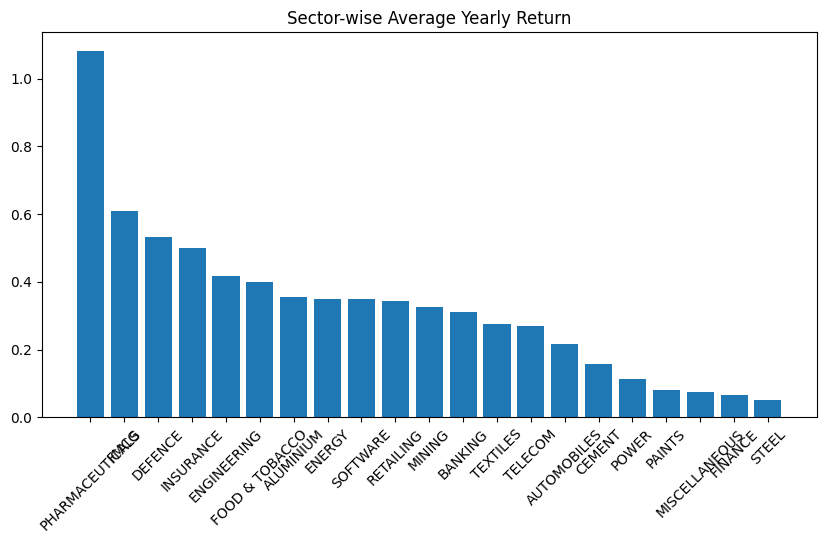

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(sector_performance["sector"], sector_performance["yearly_return"])
plt.xticks(rotation=45)
plt.title("Sector-wise Average Yearly Return")
plt.show()

In [100]:
# Merge return and volatility if not already merged
final_metrics = yearly_return.merge(volatility, on="symbol")

# Avoid division by zero
final_metrics["sharpe_ratio"] = (
    final_metrics["yearly_return"] / final_metrics["volatility"]
)

final_metrics.sort_values("sharpe_ratio", ascending=False).head(10)

,symbol,yearly_return,volatility,sharpe_ratio
13,DRREDDY,2.230926,0.023074,96.686555
14,EICHERMOT,0.695990,0.013625,51.083716
49,WIPRO,0.890112,0.017609,50.547608
21,HINDUNILVR,0.959770,0.019213,49.954775
36,RELIANCE,0.572824,0.011733,48.822354
26,ITC,1.017601,0.023283,43.704997
9,BEL,0.532574,0.014295,37.256907
11,CIPLA,0.688549,0.018671,36.877132
46,TITAN,0.589767,0.016563,35.606960
42,TATAMOTORS,0.674772,0.022069,30.575742


In [102]:
top_sharpe = final_metrics.sort_values(
    "sharpe_ratio", ascending=False
).head(10)

top_sharpe

,symbol,yearly_return,volatility,sharpe_ratio
13,DRREDDY,2.230926,0.023074,96.686555
14,EICHERMOT,0.695990,0.013625,51.083716
49,WIPRO,0.890112,0.017609,50.547608
21,HINDUNILVR,0.959770,0.019213,49.954775
36,RELIANCE,0.572824,0.011733,48.822354
26,ITC,1.017601,0.023283,43.704997
9,BEL,0.532574,0.014295,37.256907
11,CIPLA,0.688549,0.018671,36.877132
46,TITAN,0.589767,0.016563,35.606960
42,TATAMOTORS,0.674772,0.022069,30.575742


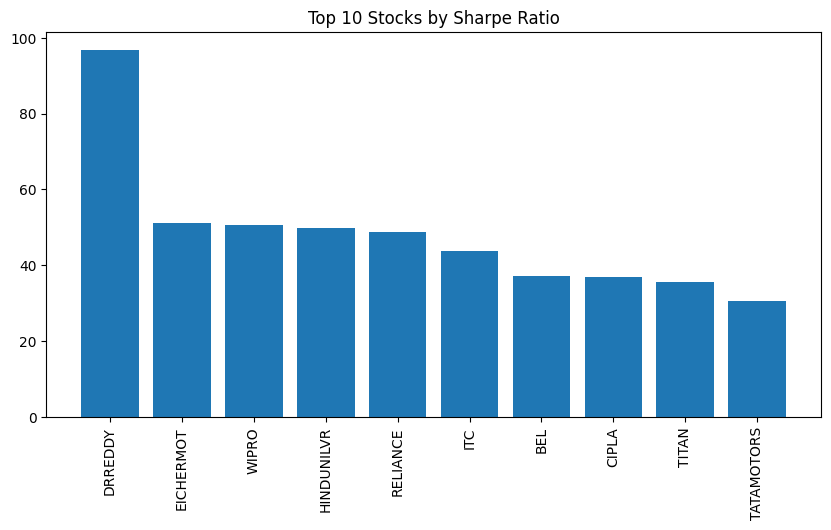

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(top_sharpe["symbol"], top_sharpe["sharpe_ratio"])
plt.xticks(rotation=90)
plt.title("Top 10 Stocks by Sharpe Ratio")
plt.show()

In [106]:
top5 = final_metrics.sort_values(
    "sharpe_ratio", ascending=False
).head(5)

top5

,symbol,yearly_return,volatility,sharpe_ratio
13,DRREDDY,2.230926,0.023074,96.686555
14,EICHERMOT,0.695990,0.013625,51.083716
49,WIPRO,0.890112,0.017609,50.547608
21,HINDUNILVR,0.959770,0.019213,49.954775
36,RELIANCE,0.572824,0.011733,48.822354


In [108]:
portfolio_return = top5["yearly_return"].mean()
portfolio_return

1.0699243872247561

In [110]:
portfolio_volatility = top5["volatility"].mean()
portfolio_volatility

0.017050654497567614

In [114]:
portfolio_sharpe = portfolio_return / portfolio_volatility
portfolio_sharpe

62.749754701638444

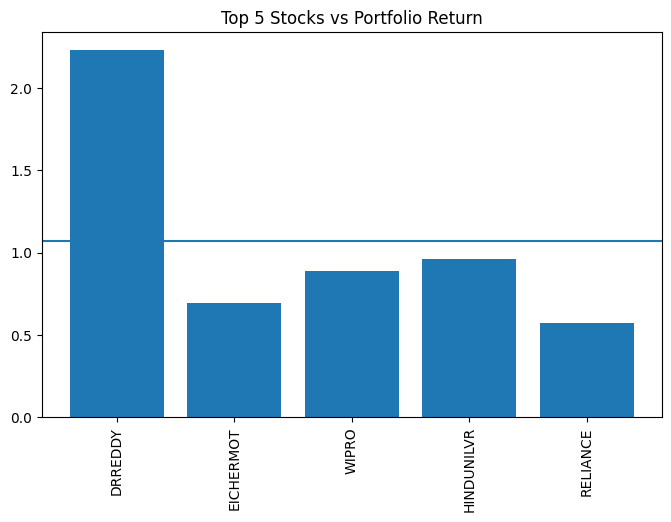

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(top5["symbol"], top5["yearly_return"])
plt.axhline(portfolio_return)
plt.xticks(rotation=90)
plt.title("Top 5 Stocks vs Portfolio Return")
plt.show()

In [118]:
best_stock = top5.iloc[0]["symbol"]

stock_df = df[df["symbol"] == best_stock].copy()
stock_df = stock_df.sort_values("date")

stock_df.head()

,date,symbol,open,high,low,close,volume,daily_return,cumulative_return
3692,2023-10-03 05:30:00,DRREDDY,2074.30,2086.30,2052.0,2059.10,543387,NaN,NaN
3693,2023-10-04 05:30:00,DRREDDY,2054.00,2055.95,2007.6,2022.30,551771,-0.017872,0.982128
3694,2023-10-05 05:30:00,DRREDDY,2022.95,2058.15,2022.3,2047.60,461744,0.012511,0.994415
3695,2023-10-06 05:30:00,DRREDDY,2055.85,2091.90,2050.1,2072.10,444220,0.011965,1.006313
3696,2023-10-09 05:30:00,DRREDDY,2035.00,2089.45,2032.4,2079.05,487722,0.003354,1.009689


In [120]:
stock_df["MA20"] = stock_df["close"].rolling(window=20).mean()
stock_df["MA50"] = stock_df["close"].rolling(window=50).mean()

stock_df.tail()

,date,symbol,open,high,low,close,volume,daily_return,cumulative_return,MA20,MA50
3971,2024-11-14 05:30:00,DRREDDY,6496.00,6550.3,6367.05,6463.00,620489,-0.005425,3.138750,7062.1575,7372.320
3972,2024-11-18 05:30:00,DRREDDY,6411.60,6453.0,6275.00,6301.65,828906,-0.024965,3.060390,6988.8375,7355.000
3973,2024-11-19 05:30:00,DRREDDY,6359.85,6579.9,6359.80,6423.85,674042,0.019392,3.119737,6929.7025,7341.406
3974,2024-11-21 05:30:00,DRREDDY,6400.00,6519.0,6346.20,6460.45,1511541,0.005698,3.137512,6877.8575,7327.882
3975,2024-11-22 05:30:00,DRREDDY,6459.90,6678.0,6430.00,6652.80,833104,0.029773,3.230926,6834.9325,7318.179


In [122]:
stock_df["signal"] = 0

stock_df.loc[stock_df["MA20"] > stock_df["MA50"], "signal"] = 1
stock_df.loc[stock_df["MA20"] < stock_df["MA50"], "signal"] = -1

stock_df.tail()

,date,symbol,open,high,low,close,volume,daily_return,cumulative_return,MA20,MA50,signal
3971,2024-11-14 05:30:00,DRREDDY,6496.00,6550.3,6367.05,6463.00,620489,-0.005425,3.138750,7062.1575,7372.320,-1
3972,2024-11-18 05:30:00,DRREDDY,6411.60,6453.0,6275.00,6301.65,828906,-0.024965,3.060390,6988.8375,7355.000,-1
3973,2024-11-19 05:30:00,DRREDDY,6359.85,6579.9,6359.80,6423.85,674042,0.019392,3.119737,6929.7025,7341.406,-1
3974,2024-11-21 05:30:00,DRREDDY,6400.00,6519.0,6346.20,6460.45,1511541,0.005698,3.137512,6877.8575,7327.882,-1
3975,2024-11-22 05:30:00,DRREDDY,6459.90,6678.0,6430.00,6652.80,833104,0.029773,3.230926,6834.9325,7318.179,-1


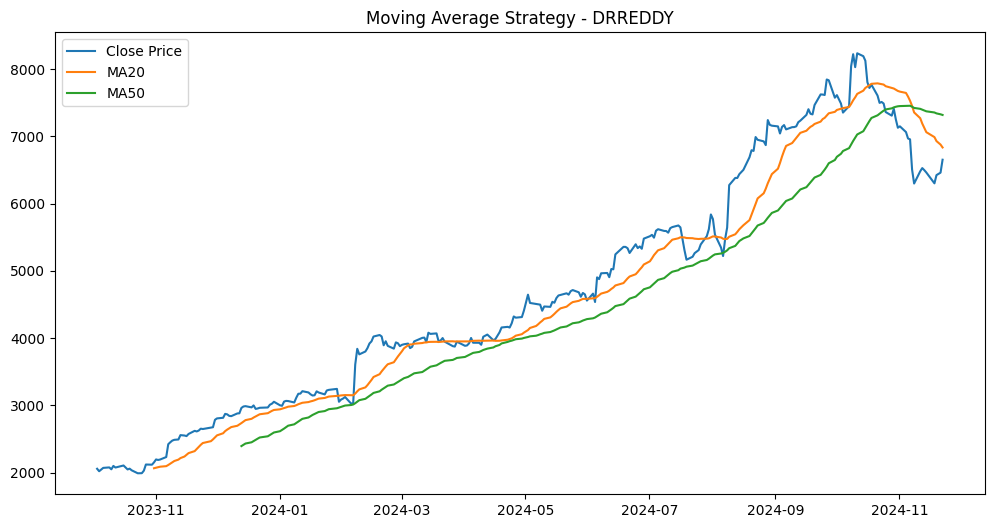

In [124]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(stock_df["date"], stock_df["close"], label="Close Price")
plt.plot(stock_df["date"], stock_df["MA20"], label="MA20")
plt.plot(stock_df["date"], stock_df["MA50"], label="MA50")

plt.legend()
plt.title(f"Moving Average Strategy - {best_stock}")
plt.show()

In [136]:
import os
print(os.getcwd())

C:\Users\karth\PycharmProjects\stock analysis


In [138]:
print(os.listdir())

['.ipynb_checkpoints', 'financial_analysis.ipynb', 'master_stock_data.csv', 'Untitled.ipynb']
